# Eye Liquid Spread Analysis - Control vs Glaucoma (with/without Uramox)

Group analysis comparing all three groups:
- **CONTROL**
- **GLAUCOMA + URAMOX** (Glaucoma patients with Uramox treatment)
- **GLAUCOMA - URAMOX** (Glaucoma patients without Uramox treatment)

**Comparisons:**
- Area over time (mean ± SD) by group
- Final area comparison (box plot + pairwise Mann-Whitney U tests)
- Velocity over time (mean ± SD) by group
- Mean and Max velocity comparison (box plot + pairwise Mann-Whitney U tests)

**Prerequisites:** Run `01_data_processing.ipynb` first to generate the data files.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

In [40]:
# Configuration
RESULTS_DIR = Path('./results')

# Define groups and colors (match 02, 13, 15)
GROUP_ORDER = ['CONTROL', 'GLAUCOMA + URAMOX', 'GLAUCOMA - URAMOX']
group_colors = {
    'CONTROL': '#377EB8',
    'GLAUCOMA + URAMOX': '#4DAF4A',
    'GLAUCOMA - URAMOX': '#E41A1C',
}
LABEL_MAP = {
    'CONTROL': 'control',
    'GLAUCOMA + URAMOX': 'glaucoma with oral acetazolamide',
    'GLAUCOMA - URAMOX': 'glaucoma without oral acetazolamide',
}


## Load Data

In [41]:
# Load measurements
df_areas = pd.read_csv(RESULTS_DIR / 'eye_liquid_spread_measurements.csv')

print(f"Loaded {len(df_areas)} measurements from {df_areas['case'].nunique()} cases")
display(df_areas.head())

Loaded 934 measurements from 23 cases


,case,slide,time_sec,area_cm2,red_pixel_count,velocity_cm2_per_sec,group,condition
0,Case#1,Slide2.png,0.00,1.455394,30856,NaN,CONTROL,CONTROL
1,Case#1,Slide3.png,0.25,1.641941,34811,0.746187,CONTROL,CONTROL
2,Case#1,Slide4.png,0.50,1.845374,39124,0.813730,CONTROL,CONTROL
3,Case#1,Slide5.png,0.75,1.999564,42393,0.616760,CONTROL,CONTROL
4,Case#1,Slide6.png,1.00,2.154555,45679,0.619967,CONTROL,CONTROL


In [42]:
# Filter to only cases with assigned groups
df_grouped = df_areas[df_areas['group'].notna()].copy()

# Get unique groups present in data
groups_present = [g for g in GROUP_ORDER if g in df_grouped['group'].unique()]

print("Cases per group:")
display(df_grouped.groupby('group')['case'].nunique().rename('n_cases'))

Cases per group:


group
CONTROL               8
GLAUCOMA + URAMOX    10
GLAUCOMA - URAMOX     5
Name: n_cases, dtype: int64

In [43]:
def pairwise_mannwhitneyu(data_dict, metric_name="metric"):
    """
    Perform pairwise Mann-Whitney U tests between all groups.
    
    Parameters:
    - data_dict: dict mapping group name to array of values
    - metric_name: name of the metric for display
    
    Returns:
    - DataFrame with pairwise comparison results
    """
    results = []
    groups = list(data_dict.keys())
    
    for g1, g2 in combinations(groups, 2):
        stat, pval = stats.mannwhitneyu(data_dict[g1], data_dict[g2], alternative='two-sided')
        results.append({
            'Comparison': f"{g1} vs {g2}",
            'Group 1': g1,
            'Group 2': g2,
            'N1': len(data_dict[g1]),
            'N2': len(data_dict[g2]),
            'U statistic': stat,
            'p-value': pval,
            'Significant': '*' if pval < 0.05 else ''
        })
    
    return pd.DataFrame(results)

## Area Comparison by Group

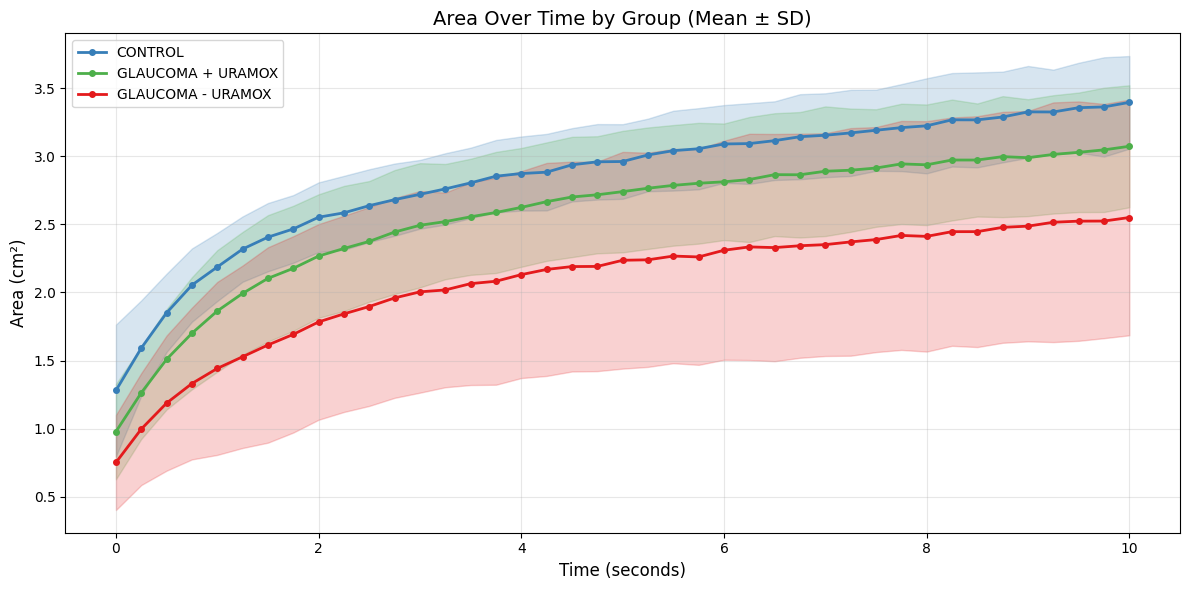

In [44]:
# Plot: Area over time by group (mean ± std)
fig, ax = plt.subplots(figsize=(12, 6))

for group in groups_present:
    group_data = df_grouped[df_grouped['group'] == group]
    stats_grp = group_data.groupby('time_sec')['area_cm2'].agg(['mean', 'std'])
    
    ax.plot(stats_grp.index, stats_grp['mean'], 'o-', label=LABEL_MAP.get(group, group), 
            color=group_colors[group], markersize=4, linewidth=2)
    ax.fill_between(stats_grp.index, 
                    stats_grp['mean'] - stats_grp['std'], 
                    stats_grp['mean'] + stats_grp['std'], 
                    alpha=0.2, color=group_colors[group])

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area Over Time by Group (Mean ± SD)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/03_area_over_time_mean_sd.png', dpi=300, bbox_inches='tight')
plt.show()

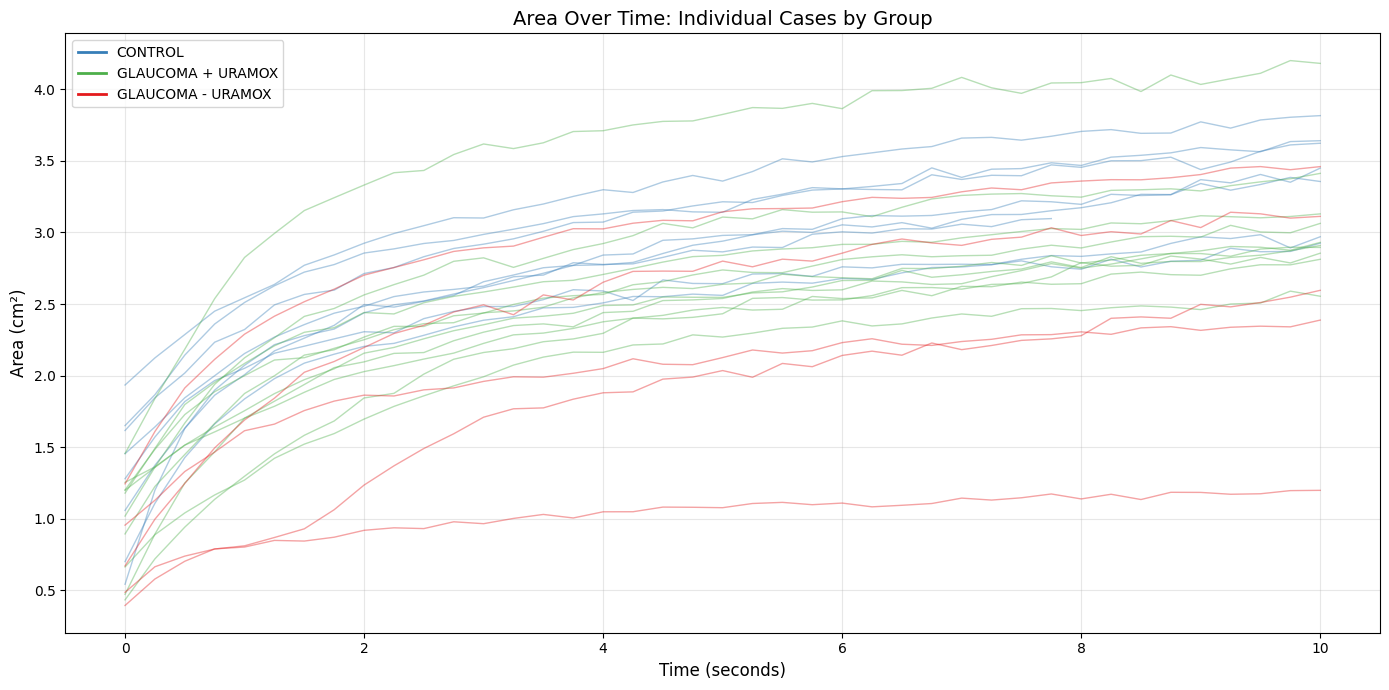

In [45]:
# Plot: Individual cases by group
fig, ax = plt.subplots(figsize=(14, 7))

for group in groups_present:
    group_data = df_grouped[df_grouped['group'] == group]
    for case in group_data['case'].unique():
        case_data = group_data[group_data['case'] == case]
        ax.plot(case_data['time_sec'], case_data['area_cm2'], '-', 
                color=group_colors[group], alpha=0.4, linewidth=1)

# Legend
for group in groups_present:
    ax.plot([], [], '-', color=group_colors[group], label=LABEL_MAP.get(group, group), linewidth=2)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area Over Time: Individual Cases by Group', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/03_area_over_time_individual.png', dpi=300, bbox_inches='tight')
plt.show()

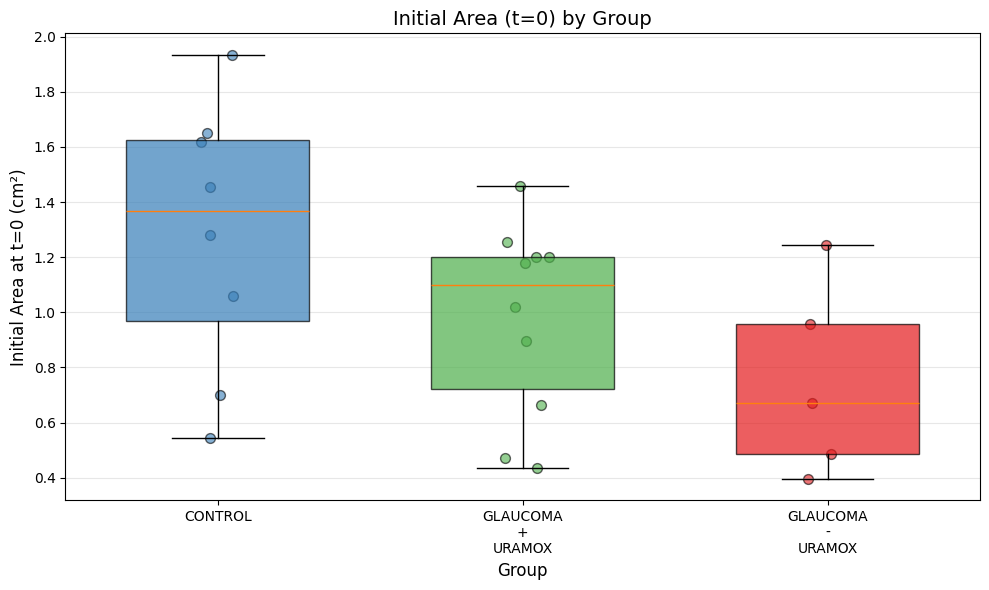

Kruskal-Wallis test (Initial Area at t=0): H = 5.1043, p-value = 0.0779

Pairwise Mann-Whitney U Tests: Initial Area


,Comparison,Group 1,Group 2,N1,N2,U statistic,p-value,Significant
0,CONTROL vs GLAUCOMA + URAMOX,CONTROL,GLAUCOMA + URAMOX,8,10,58.0,0.121989,
1,CONTROL vs GLAUCOMA - URAMOX,CONTROL,GLAUCOMA - URAMOX,8,5,34.0,0.045066,*
2,GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX,GLAUCOMA + URAMOX,GLAUCOMA - URAMOX,10,5,33.0,0.370962,


  CONTROL: mean = 1.280, std = 0.452 cm² (n=8)
  GLAUCOMA + URAMOX: mean = 0.978, std = 0.332 cm² (n=10)
  GLAUCOMA - URAMOX: mean = 0.751, std = 0.312 cm² (n=5)


In [46]:
# Box plot: Initial area (t=0) by group with pairwise Mann-Whitney U tests
initial_areas = df_grouped[df_grouped['time_sec'] == 0.0][['case', 'group', 'area_cm2']].copy()

fig, ax = plt.subplots(figsize=(10, 6))
box_data = [initial_areas[initial_areas['group'] == g]['area_cm2'].values for g in groups_present]

bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(g, g).replace(' ', '\n') for g in groups_present],
                patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

for i, group in enumerate(groups_present):
    y = initial_areas[initial_areas['group'] == group]['area_cm2'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('Initial Area at t=0 (cm²)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Initial Area (t=0) by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig('figures/03_initial_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Kruskal-Wallis test (omnibus)
kw_groups = [initial_areas[initial_areas['group'] == g]['area_cm2'].values for g in groups_present]
kw_stat, kw_pvalue = stats.kruskal(*kw_groups)
print(f"Kruskal-Wallis test (Initial Area at t=0): H = {kw_stat:.4f}, p-value = {kw_pvalue:.4f}")

# Pairwise Mann-Whitney U tests
initial_area_data = {g: initial_areas[initial_areas['group'] == g]['area_cm2'].values for g in groups_present}
initial_area_data = pairwise_mannwhitneyu(initial_area_data, metric_name="Initial Area (t=0)")

print("\nPairwise Mann-Whitney U Tests: Initial Area")
display(initial_area_data)

# Print group means
for g in groups_present:
    vals = initial_areas[initial_areas['group'] == g]['area_cm2'].values
    print(f"  {g}: mean = {vals.mean():.3f}, std = {vals.std():.3f} cm² (n={len(vals)})")

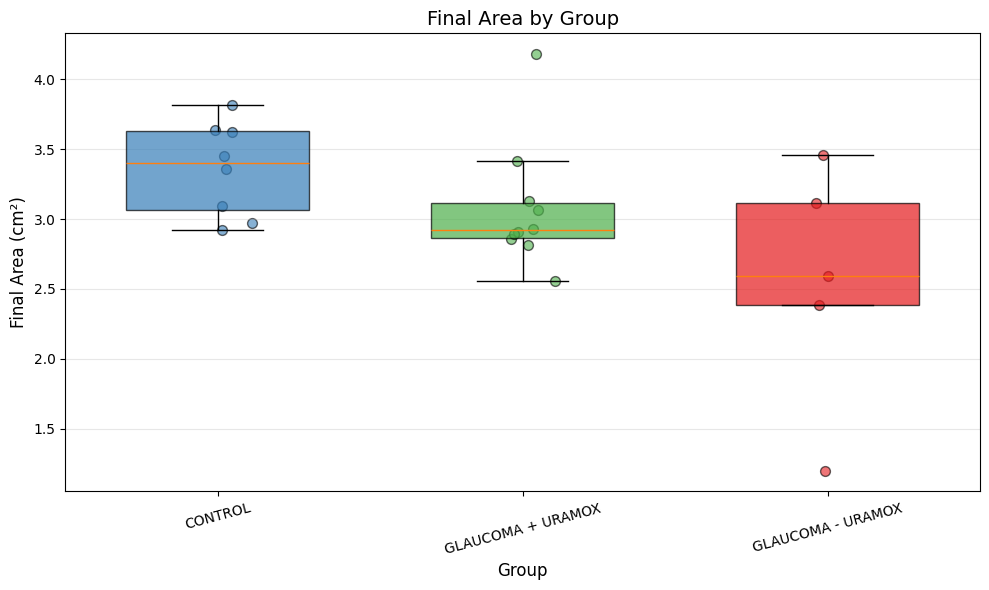

In [47]:
# Box plot: Final area by group
idx_max_time = df_grouped.groupby('case')['time_sec'].idxmax()
final_areas = df_grouped.loc[idx_max_time].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
box_data = [final_areas[final_areas['group'] == g]['area_cm2'].values for g in groups_present]

bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(g, g) for g in groups_present], patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

# Add individual points
for i, group in enumerate(groups_present):
    y = final_areas[final_areas['group'] == group]['area_cm2'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('Final Area (cm²)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Final Area by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig('figures/03_final_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# Kruskal-Wallis test (omnibus)
kw_groups = [final_areas[final_areas['group'] == g]['area_cm2'].values for g in groups_present]
kw_stat, kw_pvalue = stats.kruskal(*kw_groups)
print(f"Kruskal-Wallis test (Final Area): H = {kw_stat:.4f}, p-value = {kw_pvalue:.4f}")

# Pairwise Mann-Whitney U tests
area_data = {g: final_areas[final_areas['group'] == g]['area_cm2'].values for g in groups_present}
area_pairwise = pairwise_mannwhitneyu(area_data, "Final Area")

print("\nPairwise Mann-Whitney U Tests: Final Area")
display(area_pairwise)

Kruskal-Wallis test (Final Area): H = 5.3065, p-value = 0.0704

Pairwise Mann-Whitney U Tests: Final Area


,Comparison,Group 1,Group 2,N1,N2,U statistic,p-value,Significant
0,CONTROL vs GLAUCOMA + URAMOX,CONTROL,GLAUCOMA + URAMOX,8,10,62.0,0.054527,
1,CONTROL vs GLAUCOMA - URAMOX,CONTROL,GLAUCOMA - URAMOX,8,5,32.0,0.093240,
2,GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX,GLAUCOMA + URAMOX,GLAUCOMA - URAMOX,10,5,33.0,0.370962,


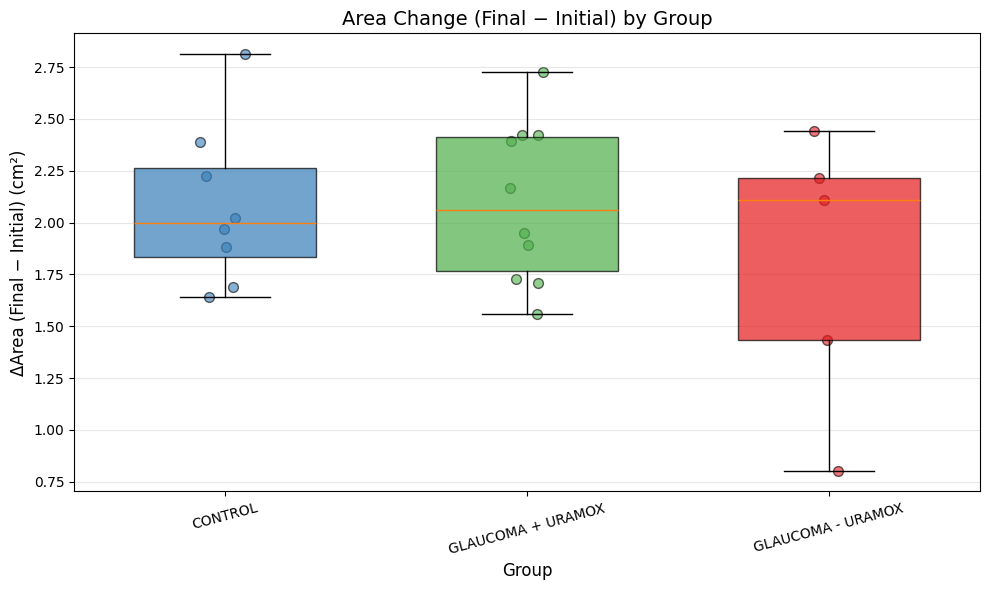

Kruskal-Wallis test (Delta Area): H = 0.4174, p-value = 0.8116

Pairwise Mann-Whitney U Tests: Delta Area


,Comparison,Group 1,Group 2,N1,N2,U statistic,p-value,Significant
0,CONTROL vs GLAUCOMA + URAMOX,CONTROL,GLAUCOMA + URAMOX,8,10,37.0,0.828557,
1,CONTROL vs GLAUCOMA - URAMOX,CONTROL,GLAUCOMA - URAMOX,8,5,23.0,0.724165,
2,GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX,GLAUCOMA + URAMOX,GLAUCOMA - URAMOX,10,5,30.0,0.594073,


In [49]:
# Box plot: Delta area (final - initial) by group with Kruskal-Wallis + pairwise Mann-Whitney
initial_areas_g = df_grouped[df_grouped['time_sec'] == 0.0][['case', 'group', 'area_cm2']].copy()
initial_areas_g = initial_areas_g.rename(columns={'area_cm2': 'initial_area'})

idx_max_time_g = df_grouped.groupby('case')['time_sec'].idxmax()
final_areas_g = df_grouped.loc[idx_max_time_g][['case', 'area_cm2']].reset_index(drop=True)
final_areas_g = final_areas_g.rename(columns={'area_cm2': 'final_area'})

delta_df = initial_areas_g.merge(final_areas_g, on='case')
delta_df['delta_area'] = delta_df['final_area'] - delta_df['initial_area']

fig, ax = plt.subplots(figsize=(10, 6))
box_data_d = [delta_df[delta_df['group'] == g]['delta_area'].values for g in groups_present]

bp = ax.boxplot(box_data_d, labels=[LABEL_MAP.get(g, g) for g in groups_present], patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

for i, group in enumerate(groups_present):
    y = delta_df[delta_df['group'] == group]['delta_area'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('ΔArea (Final − Initial) (cm²)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Area Change (Final − Initial) by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig('figures/03_delta_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Kruskal-Wallis test (omnibus)
kw_delta_groups = [delta_df[delta_df['group'] == g]['delta_area'].values for g in groups_present]
kw_delta_stat, kw_delta_pvalue = stats.kruskal(*kw_delta_groups)
print(f"Kruskal-Wallis test (Delta Area): H = {kw_delta_stat:.4f}, p-value = {kw_delta_pvalue:.4f}")

# Pairwise Mann-Whitney U tests
delta_data = {g: delta_df[delta_df['group'] == g]['delta_area'].values for g in groups_present}
delta_pairwise = pairwise_mannwhitneyu(delta_data, "Delta Area")

print("\nPairwise Mann-Whitney U Tests: Delta Area")
display(delta_pairwise)

In [50]:
# Area statistics by group
area_stats_by_group = df_grouped.groupby('group')['area_cm2'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
area_stats_by_group.columns = ['N observations', 'Mean Area', 'Std Area', 'Min Area', 'Max Area']

final_area_stats = final_areas.groupby('group')['area_cm2'].agg(['count', 'mean', 'std']).round(4)
final_area_stats.columns = ['N cases', 'Mean Final Area', 'Std Final Area']

print("\nArea Statistics by Group")
print("\nAll time points:")
display(area_stats_by_group.loc[groups_present])
print("\nFinal area per case:")
display(final_area_stats.loc[groups_present])


Area Statistics by Group

All time points:


,N observations,Mean Area,Std Area,Min Area,Max Area
group,,,,,
CONTROL,319,2.8278,0.5646,0.5433,3.8157
GLAUCOMA + URAMOX,410,2.5618,0.6510,0.4344,4.2001
GLAUCOMA - URAMOX,205,2.0762,0.8145,0.3953,3.4599



Final area per case:


,N cases,Mean Final Area,Std Final Area
group,,,
CONTROL,8,3.3594,0.3326
GLAUCOMA + URAMOX,10,3.0743,0.4482
GLAUCOMA - URAMOX,5,2.5510,0.8655


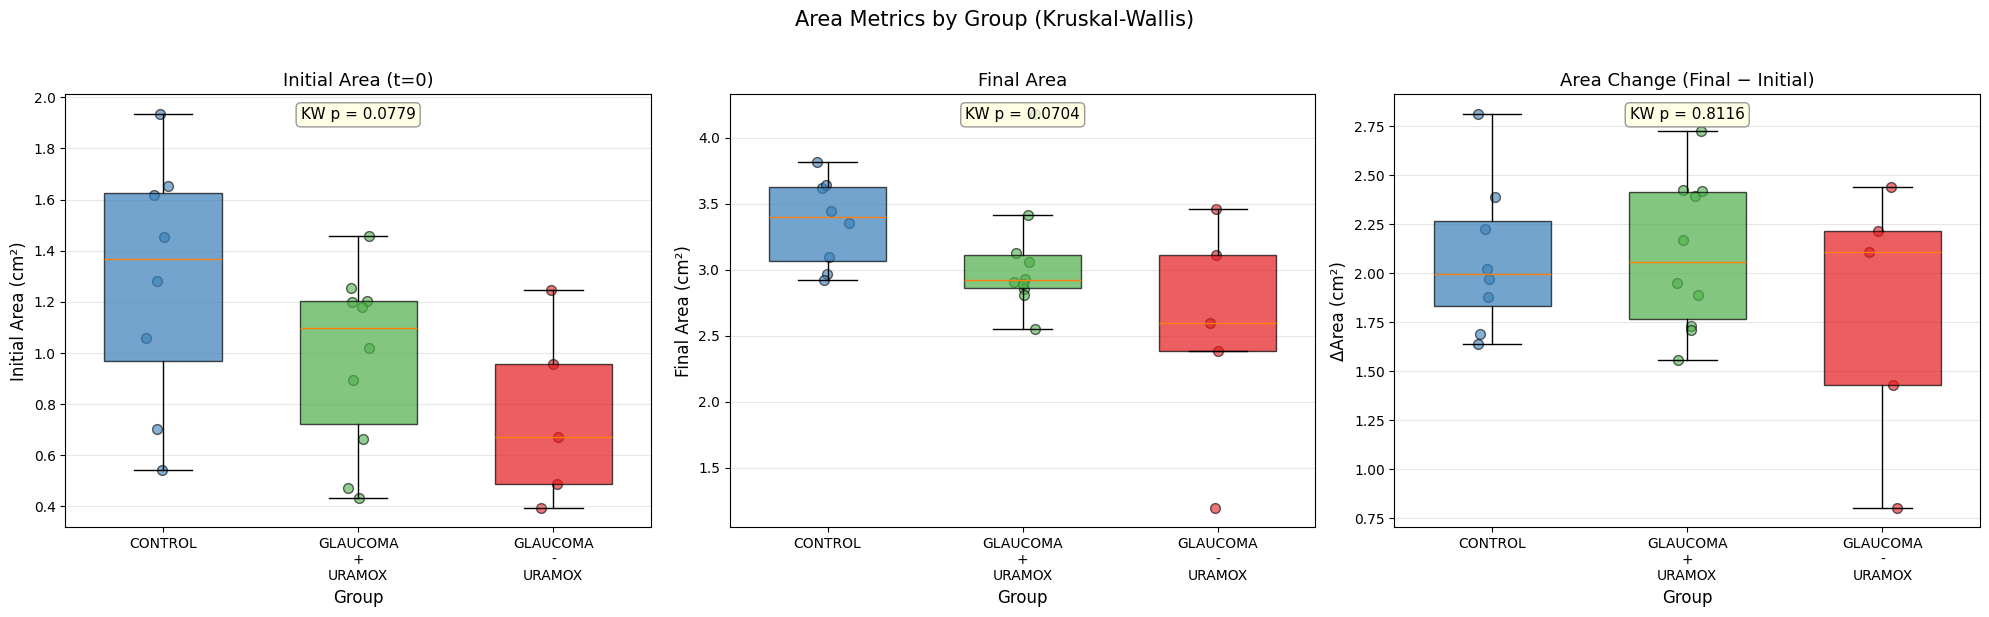

In [51]:
# Combined figure: Initial Area, Final Area, Area Change with Kruskal-Wallis tests
initial_areas = df_grouped[df_grouped['time_sec'] == 0.0][['case', 'group', 'area_cm2']].copy()

idx_max_time = df_grouped.groupby('case')['time_sec'].idxmax()
final_areas_all = df_grouped.loc[idx_max_time][['case', 'group', 'area_cm2']].reset_index(drop=True)

delta_df_all = initial_areas.rename(columns={'area_cm2': 'initial_area'}).merge(
    final_areas_all.rename(columns={'area_cm2': 'final_area'})[['case', 'final_area']], on='case')
delta_df_all['delta_area'] = delta_df_all['final_area'] - delta_df_all['initial_area']

datasets = [
    {'data': initial_areas, 'col': 'area_cm2', 'ylabel': 'Initial area (cm²)', 'title': 'Initial area (t=0)'},
    {'data': final_areas_all, 'col': 'area_cm2', 'ylabel': 'Final area (cm²)', 'title': 'Final area'},
    {'data': delta_df_all, 'col': 'delta_area', 'ylabel': 'ΔArea (cm²)', 'title': 'Area change (final − initial)'},
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, ds in zip(axes, datasets):
    df_plot = ds['data']
    col = ds['col']

    kw_data = [df_plot[df_plot['group'] == g][col].values for g in groups_present]
    kw_stat, kw_pval = stats.kruskal(*kw_data)

    bp = ax.boxplot(kw_data, labels=[LABEL_MAP.get(g, g).replace(' ', '\n') for g in groups_present],
                    patch_artist=True, widths=0.6, showfliers=False)
    for patch, group in zip(bp['boxes'], groups_present):
        patch.set_facecolor(group_colors[group])
        patch.set_alpha(0.7)

    for i, group in enumerate(groups_present):
        y = df_plot[df_plot['group'] == group][col].values
        x = np.random.normal(i + 1, 0.04, size=len(y))
        ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

    kw_text = f'KW p = {kw_pval:.4f}' if kw_pval >= 0.0001 else 'KW p < 0.0001'
    if kw_pval < 0.05:
        kw_text += ' *'
    ax.text(0.5, 0.97, kw_text, transform=ax.transAxes, ha='center', va='top',
            fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

    ax.set_ylabel(ds['ylabel'], fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_title(ds['title'], fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('figures/03_area_combined_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## Velocity Comparison by Group

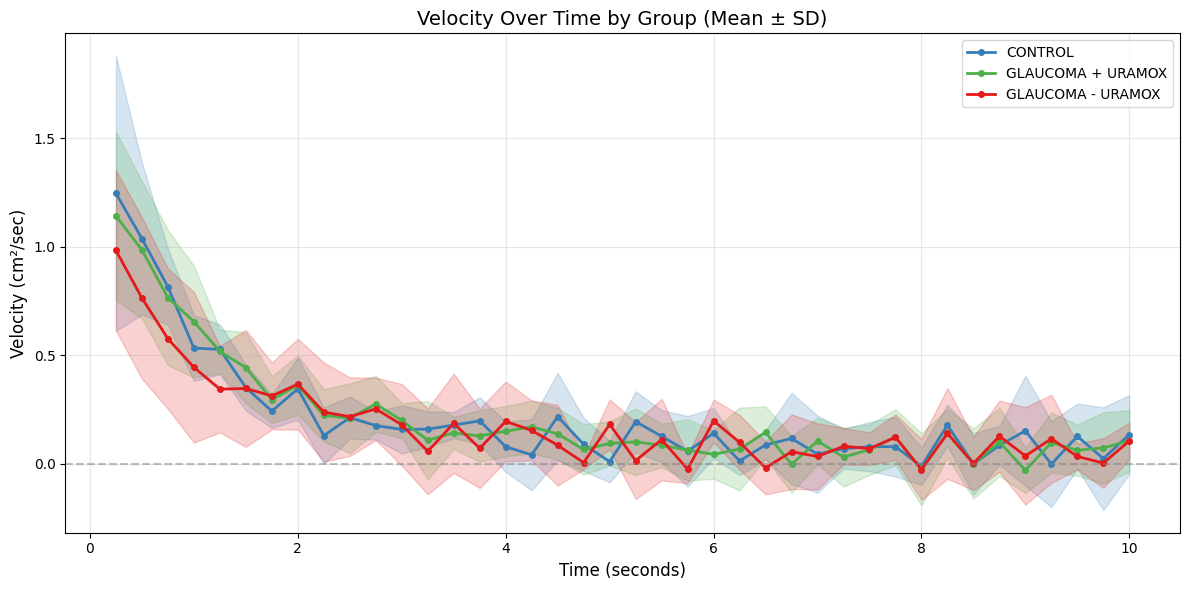

In [52]:
# Plot: Velocity over time by group (mean ± std)
fig, ax = plt.subplots(figsize=(12, 6))

for group in groups_present:
    group_data = df_grouped[df_grouped['group'] == group]
    stats_grp = group_data.groupby('time_sec')['velocity_cm2_per_sec'].agg(['mean', 'std'])
    
    ax.plot(stats_grp.index, stats_grp['mean'], 'o-', label=LABEL_MAP.get(group, group), 
            color=group_colors[group], markersize=4, linewidth=2)
    ax.fill_between(stats_grp.index, 
                    stats_grp['mean'] - stats_grp['std'], 
                    stats_grp['mean'] + stats_grp['std'], 
                    alpha=0.2, color=group_colors[group])

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Velocity (cm²/sec)', fontsize=12)
ax.set_title('Velocity Over Time by Group (Mean ± SD)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/03_velocity_over_time_mean_sd.png', dpi=300, bbox_inches='tight')
plt.show()

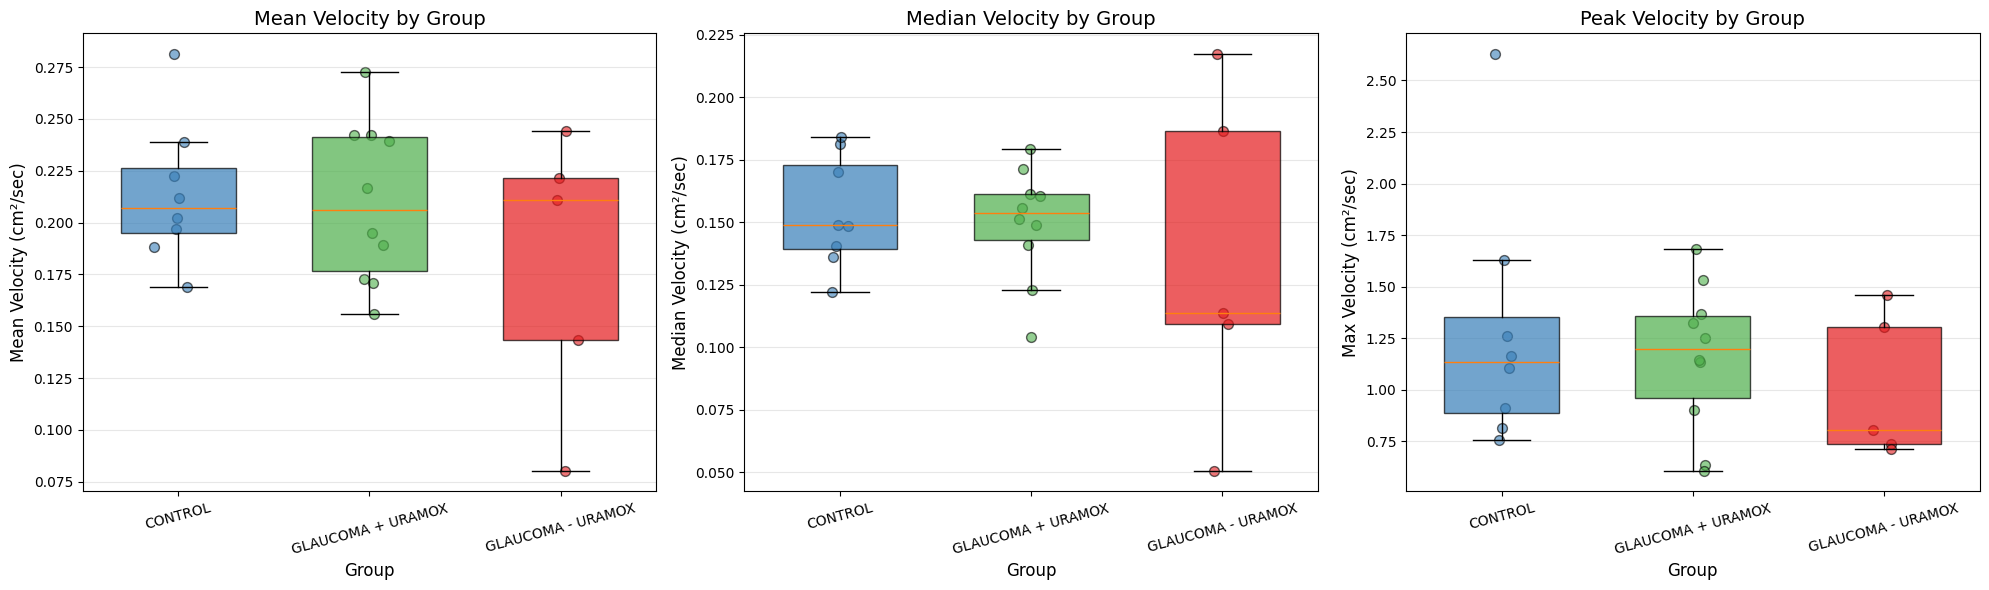

In [53]:
# Box plots: Mean, Median, and Max velocity by group
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Mean velocity per case
mean_velocities = df_grouped.groupby('case').agg({
    'velocity_cm2_per_sec': 'mean',
    'group': 'first'
}).reset_index()

ax = axes[0]
box_data = [mean_velocities[mean_velocities['group'] == g]['velocity_cm2_per_sec'].values for g in groups_present]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(g, g) for g in groups_present], patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

for i, group in enumerate(groups_present):
    y = mean_velocities[mean_velocities['group'] == group]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('Mean Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Mean Velocity by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=15)

# Median velocity per case
median_velocities = df_grouped.groupby('case').agg({
    'velocity_cm2_per_sec': 'median',
    'group': 'first'
}).reset_index()

ax = axes[1]
box_data = [median_velocities[median_velocities['group'] == g]['velocity_cm2_per_sec'].values for g in groups_present]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(g, g) for g in groups_present], patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

for i, group in enumerate(groups_present):
    y = median_velocities[median_velocities['group'] == group]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('Median Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Median Velocity by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=15)

# Max velocity per case
max_velocities = df_grouped.groupby('case').agg({
    'velocity_cm2_per_sec': 'max',
    'group': 'first'
}).reset_index()

ax = axes[2]
box_data = [max_velocities[max_velocities['group'] == g]['velocity_cm2_per_sec'].values for g in groups_present]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(g, g) for g in groups_present], patch_artist=True, widths=0.6, showfliers=False)
for patch, group in zip(bp['boxes'], groups_present):
    patch.set_facecolor(group_colors[group])
    patch.set_alpha(0.7)

for i, group in enumerate(groups_present):
    y = max_velocities[max_velocities['group'] == group]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=group_colors[group], edgecolor='black', s=50)

ax.set_ylabel('Max Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_title('Peak Velocity by Group', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
fig.savefig('figures/03_velocity_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
# Pairwise Mann-Whitney U tests for mean velocity
mean_vel_data = {g: mean_velocities[mean_velocities['group'] == g]['velocity_cm2_per_sec'].values for g in groups_present}
mean_vel_pairwise = pairwise_mannwhitneyu(mean_vel_data, "Mean Velocity")

print("\nPairwise Mann-Whitney U Tests: Mean Velocity")
display(mean_vel_pairwise)


Pairwise Mann-Whitney U Tests: Mean Velocity


,Comparison,Group 1,Group 2,N1,N2,U statistic,p-value,Significant
0,CONTROL vs GLAUCOMA + URAMOX,CONTROL,GLAUCOMA + URAMOX,8,10,41.0,0.965401,
1,CONTROL vs GLAUCOMA - URAMOX,CONTROL,GLAUCOMA - URAMOX,8,5,24.0,0.621601,
2,GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX,GLAUCOMA + URAMOX,GLAUCOMA - URAMOX,10,5,30.0,0.594073,


In [55]:
# Pairwise Mann-Whitney U tests for max velocity
max_vel_data = {g: max_velocities[max_velocities['group'] == g]['velocity_cm2_per_sec'].values for g in groups_present}
max_vel_pairwise = pairwise_mannwhitneyu(max_vel_data, "Max Velocity")

print("\nPairwise Mann-Whitney U Tests: Max Velocity")
display(max_vel_pairwise)


Pairwise Mann-Whitney U Tests: Max Velocity


,Comparison,Group 1,Group 2,N1,N2,U statistic,p-value,Significant
0,CONTROL vs GLAUCOMA + URAMOX,CONTROL,GLAUCOMA + URAMOX,8,10,40.0,1.000000,
1,CONTROL vs GLAUCOMA - URAMOX,CONTROL,GLAUCOMA - URAMOX,8,5,27.0,0.354312,
2,GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX,GLAUCOMA + URAMOX,GLAUCOMA - URAMOX,10,5,30.0,0.594073,


In [56]:
# Velocity statistics by group
velocity_stats_by_group = df_grouped.groupby('group')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
velocity_stats_by_group.columns = ['N observations', 'Mean Velocity', 'Std Velocity', 'Min Velocity', 'Max Velocity']

mean_vel_stats = mean_velocities.groupby('group')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std']).round(4)
mean_vel_stats.columns = ['N cases', 'Mean of Mean Velocity', 'Std of Mean Velocity']

max_vel_stats = max_velocities.groupby('group')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std']).round(4)
max_vel_stats.columns = ['N cases', 'Mean of Max Velocity', 'Std of Max Velocity']

print("\nVelocity Statistics by Group")
print("\nAll time points:")
display(velocity_stats_by_group.loc[groups_present])
print("\nMean velocity per case:")
display(mean_vel_stats.loc[groups_present])
print("\nMax velocity per case:")
display(max_vel_stats.loc[groups_present])


Velocity Statistics by Group

All time points:


,N observations,Mean Velocity,Std Velocity,Min Velocity,Max Velocity
group,,,,,
CONTROL,311,0.2139,0.3176,-0.3686,2.6274
GLAUCOMA + URAMOX,400,0.2096,0.3012,-0.3645,1.6836
GLAUCOMA - URAMOX,200,0.1800,0.2703,-0.2773,1.4616



Mean velocity per case:


,N cases,Mean of Mean Velocity,Std of Mean Velocity
group,,,
CONTROL,8,0.2139,0.0345
GLAUCOMA + URAMOX,10,0.2096,0.0386
GLAUCOMA - URAMOX,5,0.1800,0.0672



Max velocity per case:


,N cases,Mean of Max Velocity,Std of Max Velocity
group,,,
CONTROL,8,1.2844,0.6101
GLAUCOMA + URAMOX,10,1.1586,0.3556
GLAUCOMA - URAMOX,5,1.0044,0.3513


## Summary

In [57]:
print("="*70)
print("CONTROL vs GLAUCOMA (+/- URAMOX) ANALYSIS SUMMARY")
print("="*70)

print(f"\nSample sizes:")
for group in groups_present:
    n = len(area_data[group])
    print(f"  {group}: {n} cases")

print(f"\n{'='*70}")
print("AREA COMPARISON")
print("="*70)
print(f"\nFinal Area (mean ± std):")
for group in groups_present:
    vals = area_data[group]
    print(f"  {group}: {vals.mean():.3f} ± {vals.std():.3f} cm²")

print(f"\nPairwise comparisons (Mann-Whitney U):")
for _, row in area_pairwise.iterrows():
    sig = ' *' if row['Significant'] else ''
    print(f"  {row['Comparison']}: p = {row['p-value']:.4f}{sig}")

print(f"\n{'='*70}")
print("VELOCITY COMPARISON")
print("="*70)

print(f"\nMean Velocity (mean ± std):")
for group in groups_present:
    vals = mean_vel_data[group]
    print(f"  {group}: {vals.mean():.4f} ± {vals.std():.4f} cm²/sec")

print(f"\nPairwise comparisons (Mann-Whitney U):")
for _, row in mean_vel_pairwise.iterrows():
    sig = ' *' if row['Significant'] else ''
    print(f"  {row['Comparison']}: p = {row['p-value']:.4f}{sig}")

print(f"\nMax Velocity (mean ± std):")
for group in groups_present:
    vals = max_vel_data[group]
    print(f"  {group}: {vals.mean():.4f} ± {vals.std():.4f} cm²/sec")

print(f"\nPairwise comparisons (Mann-Whitney U):")
for _, row in max_vel_pairwise.iterrows():
    sig = ' *' if row['Significant'] else ''
    print(f"  {row['Comparison']}: p = {row['p-value']:.4f}{sig}")

CONTROL vs GLAUCOMA (+/- URAMOX) ANALYSIS SUMMARY

Sample sizes:
  CONTROL: 8 cases
  GLAUCOMA + URAMOX: 10 cases
  GLAUCOMA - URAMOX: 5 cases

AREA COMPARISON

Final Area (mean ± std):
  CONTROL: 3.359 ± 0.311 cm²
  GLAUCOMA + URAMOX: 3.074 ± 0.425 cm²
  GLAUCOMA - URAMOX: 2.551 ± 0.774 cm²

Pairwise comparisons (Mann-Whitney U):
  CONTROL vs GLAUCOMA + URAMOX: p = 0.0545
  CONTROL vs GLAUCOMA - URAMOX: p = 0.0932
  GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX: p = 0.3710

VELOCITY COMPARISON

Mean Velocity (mean ± std):
  CONTROL: 0.2139 ± 0.0323 cm²/sec
  GLAUCOMA + URAMOX: 0.2096 ± 0.0366 cm²/sec
  GLAUCOMA - URAMOX: 0.1800 ± 0.0601 cm²/sec

Pairwise comparisons (Mann-Whitney U):
  CONTROL vs GLAUCOMA + URAMOX: p = 0.9654
  CONTROL vs GLAUCOMA - URAMOX: p = 0.6216
  GLAUCOMA + URAMOX vs GLAUCOMA - URAMOX: p = 0.5941

Max Velocity (mean ± std):
  CONTROL: 1.2844 ± 0.5707 cm²/sec
  GLAUCOMA + URAMOX: 1.1586 ± 0.3373 cm²/sec
  GLAUCOMA - URAMOX: 1.0044 ± 0.3143 cm²/sec

Pairwise comparisons